In [43]:
import glob
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
from pandas import Timestamp
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from pyproj import Transformer
import matplotlib.colors as mcolors
from shapely.geometry import Polygon, Point
import cartopy.feature as cfeature
from scipy.stats import linregress
from datetime import datetime, timedelta
from itertools import cycle
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

### Functions

In [14]:
def get_hudson_masks(ds):
    """
    Create masks for West and South Hudson Bay based on x/y or lat/lon bounds.

    Returns:
        mask_west, mask_south : xarray.DataArray (boolean)
    """

    # Define bounds (lon/lat)
    west_bounds = {'lon_min': -95, 'lon_max': -88, 'lat_min': 56, 'lat_max': 63}
    south_bounds = {'lon_min': -88, 'lon_max': -75, 'lat_min': 51, 'lat_max': 60}

    if 'lat' in ds.coords and 'lon' in ds.coords:
        print("Using lat/lon coordinates for masking")

        mask_west = ((ds.lon >= west_bounds['lon_min']) & (ds.lon <= west_bounds['lon_max']) &
                     (ds.lat >= west_bounds['lat_min']) & (ds.lat <= west_bounds['lat_max']))

        mask_south = ((ds.lon >= south_bounds['lon_min']) & (ds.lon <= south_bounds['lon_max']) &
                      (ds.lat >= south_bounds['lat_min']) & (ds.lat <= south_bounds['lat_max']))

    elif 'x' in ds.coords and 'y' in ds.coords:
        print("Using x/y coordinates for masking")

        # Set up transformer
        transformer = Transformer.from_crs("EPSG:4326", "EPSG:3413", always_xy=True)

        # Define West polygon in lon/lat
        west_poly_lonlat = [
            (west_bounds['lon_min'], west_bounds['lat_min']),
            (west_bounds['lon_max'], west_bounds['lat_min']),
            (west_bounds['lon_max'], west_bounds['lat_max']),
            (west_bounds['lon_min'], west_bounds['lat_max']),
            (west_bounds['lon_min'], west_bounds['lat_min'])
        ]

        # Define South polygon in lon/lat
        south_poly_lonlat = [
            (south_bounds['lon_min'], south_bounds['lat_min']),
            (south_bounds['lon_max'], south_bounds['lat_min']),
            (south_bounds['lon_max'], south_bounds['lat_max']),
            (south_bounds['lon_min'], south_bounds['lat_max']),
            (south_bounds['lon_min'], south_bounds['lat_min'])
        ]

        # Transform both polygons to projected x/y
        west_poly_proj = [transformer.transform(lon, lat) for lon, lat in west_poly_lonlat]
        south_poly_proj = [transformer.transform(lon, lat) for lon, lat in south_poly_lonlat]

        # Create shapely polygons
        west_polygon = Polygon(west_poly_proj)
        south_polygon = Polygon(south_poly_proj)

        # Create 2D meshgrid of x and y coordinates from dataset
        xx, yy = np.meshgrid(ds.x.values, ds.y.values)

        # Flatten meshgrid for efficient point-in-polygon testing
        points = np.vstack((xx.ravel(), yy.ravel())).T

        # Create masks by checking if points fall inside polygons
        mask_west_flat = np.array([west_polygon.contains(Point(x, y)) for x, y in points])
        mask_south_flat = np.array([south_polygon.contains(Point(x, y)) for x, y in points])

        # Reshape masks back to 2D (y, x)
        mask_west = xr.DataArray(mask_west_flat.reshape(xx.shape), dims=('y', 'x'), coords={'y': ds.y, 'x': ds.x})
        mask_south = xr.DataArray(mask_south_flat.reshape(xx.shape), dims=('y', 'x'), coords={'y': ds.y, 'x': ds.x})

    else:
        raise ValueError("Dataset does not have expected coordinate system (lat/lon or x/y)")

    return mask_west, mask_south


def calc_breakup_freezeup_icefree(
    sic: xr.DataArray,
    extent_thresholds=[10,20,30,40,50,60,70,80,90],
    area_thresholds=[10,20,30,40,50,60,70,80,90],
    require_persistence=True,
    persistence_days=3,
) -> xr.Dataset:
    """
    Calculate breakup, freezeup and ifd dates for a single basin.

    Parameters:
        sic: xr.DataArray
            Sea ice concentration (0-100), dims: (time, y, x). Must be masked to the basin already.
        extent_thresholds: list[int]
            SIC thresholds (%) to define ice-covered grid cells.
        area_thresholds: list[int]
            % of March mean extent to define threshold for break-up/freeze-up.
        require_persistence: bool
            Whether to require `persistence_days` consecutive days below/above threshold.
        persistence_days: int
            Number of days for persistence check.

    Returns:
    xr.Dataset with dimensions (extent_threshold, area_threshold, year) containing:
        - breakup_day: Day-of-year (int) of breakup.
        - freezeup_day: Day-of-year (int) of freezeup.
        - breakup_date: Full date (datetime64) of breakup.
        - freezeup_date: Full date (datetime64) of freezeup.
        - ifd: Ice-free duration in days (freezeup_day - breakup_day), NaN if breakup or freezeup missing.
    """
    # Convert to Dask if needed
    if not sic.chunks:
        sic = sic.chunk({'time': -1, 'y': 'auto', 'x': 'auto'})

    # Ensure time is sorted
    sic = sic.sortby('time')
    years = np.unique(sic['time'].dt.year.values)

    extent_thresholds = np.array(extent_thresholds)
    area_thresholds = np.array(area_thresholds)
    n_ext, n_area, n_years = len(extent_thresholds), len(area_thresholds), len(years)

    # Get March mean extent (per threshold)
    march = sic.sel(time=sic['time'].dt.month == 3)
    march_extent_ref = []
    for e_thr in extent_thresholds:
        is_ice = (march >= e_thr)
        extent = is_ice.sum(dim=['y', 'x'])  # count of icy pixels
        avg_extent = extent.mean(dim='time').compute().item()
        march_extent_ref.append(avg_extent)
    march_extent_ref = np.array(march_extent_ref)

    # Initialize DOY arrays (float, to hold np.nan)
    breakup_day = np.full((n_ext, n_area, n_years), np.nan)
    freezeup_day = np.full((n_ext, n_area, n_years), np.nan)

    # Initialize date arrays (datetime64, to hold NaT)
    breakup_date = np.full((n_ext, n_area, n_years), np.datetime64('NaT'), dtype='datetime64[ns]')
    freezeup_date = np.full((n_ext, n_area, n_years), np.datetime64('NaT'), dtype='datetime64[ns]')

    # Loop over extent and area thresholds
    for e_idx, e_thr in enumerate(extent_thresholds):
        sic_bin = sic >= e_thr  # (time, y, x)
        extent_ts = sic_bin.sum(dim=['y', 'x'])  # (time,)
        extent_ts.load()  # load now for speed

        for a_idx, a_thr in enumerate(area_thresholds):
            extent_thresh = (a_thr / 100.0) * march_extent_ref[e_idx]

            for y_idx, year in enumerate(years):
                year_time = sic['time'].sel(time=sic['time'].dt.year == year)
                doy_max = year_time.dt.dayofyear.max().item()

                # --- Break-up ---
                jul_31 = Timestamp(f"{year}-07-31").timetuple().tm_yday
                if doy_max >= jul_31:
                    time_mask = sic['time'].dt.year == year
                    extent_y = extent_ts.sel(time=time_mask)
                    doy = extent_y['time'].dt.dayofyear

                    breakup_doy_start = Timestamp(f"{year}-04-01").timetuple().tm_yday  # Apr 1
                    breakup_doy_end = Timestamp(f"{year}-07-31").timetuple().tm_yday  # Jul 31
                    breakup_mask = (doy >= breakup_doy_start) & (doy <= breakup_doy_end)

                    cond = extent_y < extent_thresh
                    cond = cond.where(breakup_mask, drop=True)

                    if require_persistence and cond.sizes['time'] >= persistence_days:
                        roll = cond.rolling(time=persistence_days).sum()
                        valid = roll == persistence_days
                    elif not require_persistence:
                        valid = cond
                    else:
                        valid = xr.full_like(cond, False, dtype=bool)

                    valid_times = cond['time'].where(valid, drop=True)
                    if valid_times.size > 0:
                        date = pd.to_datetime(valid_times[0].item())
                        breakup_day[e_idx, a_idx, y_idx] = date.timetuple().tm_yday
                        breakup_date[e_idx, a_idx, y_idx] = np.datetime64(date)

                # --- Freeze-up ---
                dec_31 = Timestamp(f"{year}-12-31").timetuple().tm_yday
                if doy_max >= dec_31:  # Check if there's data up to December 31
                    time_window = sic['time'].dt.year == year
                    extent_f = extent_ts.sel(time=time_window)
                    doy_f = extent_f['time'].dt.dayofyear

                    freeze_start_doy = Timestamp(f"{year}-10-01").timetuple().tm_yday  # Oct 1
                    freeze_end_doy = Timestamp(f"{year}-12-31").timetuple().tm_yday  # Dec 31
                    freeze_mask = (doy_f >= freeze_start_doy) & (doy_f <= freeze_end_doy)

                    cond_f = extent_f >= extent_thresh
                    cond_f = cond_f.where(freeze_mask, drop=True)

                    if require_persistence and cond_f.sizes['time'] >= persistence_days:
                        roll_f = cond_f.rolling(time=persistence_days).sum()
                        valid_f = roll_f == persistence_days
                    elif not require_persistence:
                        valid_f = cond_f
                    else:
                        valid_f = xr.full_like(cond_f, False, dtype=bool)

                    valid_times_f = cond_f['time'].where(valid_f, drop=True)
                    if valid_times_f.size > 0:
                        date_f = pd.to_datetime(valid_times_f[0].item())
                        freezeup_day[e_idx, a_idx, y_idx] = date_f.timetuple().tm_yday
                        freezeup_date[e_idx, a_idx, y_idx] = np.datetime64(date_f)

    # Compute ifd with explicit NaN handling
    ifd = np.where(
        np.isnan(freezeup_day) | np.isnan(breakup_day),
        np.nan,
        freezeup_day - breakup_day
    )

    # Create Dataset
    ds = xr.Dataset(
        {
            "breakup_day": (["extent_threshold", "area_threshold", "year"], breakup_day),
            "freezeup_day": (["extent_threshold", "area_threshold", "year"], freezeup_day),
            "breakup_date": (["extent_threshold", "area_threshold", "year"], breakup_date),
            "freezeup_date": (["extent_threshold", "area_threshold", "year"], freezeup_date),
            "ifd": (["extent_threshold", "area_threshold", "year"], ifd)
        },
        coords={
            "extent_threshold": extent_thresholds,
            "area_threshold": area_thresholds,
            "year": years
        }
    )

    return ds


def plot_hudson_bay(ds, west_mask, south_mask):
    # Define projections
    crs = ccrs.Stereographic(
        central_latitude=90,
        central_longitude=-45
    )

    crs_nsidc = ccrs.Stereographic(
        central_latitude=90,
        central_longitude=-45,
        true_scale_latitude=70,
        false_easting=0,
        false_northing=0
    )

    # Define levels (boundaries for the colors)
    levels = np.linspace(0, 100, 11)
    norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=plt.cm.Blues_r.N, clip=True)

    # Create plot
    fig, ax = plt.subplots(1, 1, figsize=(6, 6), subplot_kw={'projection': crs})

    # Ocean
    ax.add_feature(cfeature.OCEAN.with_scale('50m'), zorder=0, facecolor='#08306B')

    # Sea ice concentration
    im = ax.pcolormesh(
        ds.x.values,
        ds.y.values,
        ds.values,
        cmap='Blues_r',
        norm=norm,
        transform=crs_nsidc,
        zorder=1
    )

    # Land
    ax.add_feature(cfeature.LAND.with_scale('50m'), zorder=2, facecolor='gray', edgecolor='black', linewidth=0.5)

    # Coastlines
    ax.coastlines(resolution='50m', zorder=3)

    # Approximate extent around Hudson Bay in degrees
    hudson_extent = [-87, -80, 49, 67]
    ax.set_extent(hudson_extent, crs=ccrs.PlateCarree())

    # Gridlines
    ax.gridlines(draw_labels=False, linewidth=0.5, alpha=0.5, color='white')

    # West and South Hudson Bay boxes
    west_bounds = {'lon_min': -95, 'lon_max': -88, 'lat_min': 56, 'lat_max': 63}
    south_bounds = {'lon_min': -88, 'lon_max': -75, 'lat_min': 51, 'lat_max': 60}

    draw_box(ax, west_bounds, edgecolor='red', linewidth=2)
    draw_box(ax, south_bounds, edgecolor='red', linewidth=2)

    ax.text(-90, 60, "West", transform=ccrs.PlateCarree(), fontsize=12, color='red', ha='center', va='center', fontweight='bold')
    ax.text(-85, 54, "South", transform=ccrs.PlateCarree(), fontsize=12, color='red', ha='center', va='center', fontweight='bold')

    # Colorbar with percentage formatting
    cbar = plt.colorbar(im, orientation='vertical', boundaries=levels, ticks=levels, pad=0.05, shrink=0.7)
    cbar.set_label('Sea Ice Concentration (%)', fontsize=12)

    # Title in same style
    date_str = ds_sel["time"].dt.strftime("%d %b %Y").item()
    ax.set_title(f'Sea Ice Concentration, {date_str}', fontsize=16, pad=20)

    plt.tight_layout()
    plt.show()


def draw_box(ax, bounds, edgecolor='red', linewidth=2):
    """
    Draw a rectangular box on a Cartopy map.

    Parameters:
    - ax: matplotlib axis with cartopy projection
    - bounds: dict with keys 'lon_min', 'lon_max', 'lat_min', 'lat_max'
    """
    # Corners of the box in lon/lat
    lons = [bounds['lon_min'], bounds['lon_max'], bounds['lon_max'], bounds['lon_min'], bounds['lon_min']]
    lats = [bounds['lat_min'], bounds['lat_min'], bounds['lat_max'], bounds['lat_max'], bounds['lat_min']]

    # Plot the box using PlateCarree projection (geodetic)
    ax.plot(lons, lats, transform=ccrs.PlateCarree(), color=edgecolor, linewidth=linewidth)

ERROR! Session/line number was not unique in database. History logging moved to new session 2315


### Metrics Comparisons

#### Load Data

In [2]:
# Combined data
vars = ['am2_seaice_conc', 'cdr_seaice_conc', 'ICECON', 'sic']

# Allocate for dataset information
names, ds_all = [], []

for file_path in glob.glob('/glade/work/skygale/pbi-data/combined/*.nc'):
    name = file_path[38:-3]
    names.append(name)
    print(f'Processing {name}...')

    # Open dataset
    ds = xr.open_dataset(file_path, chunks={})

    # Get sea ice
    for varname in vars:
        if varname in ds.data_vars:
            da = ds[varname]
            break

    # Standardize DataArray names
    rename_dict = {}
    if 'ni' in da.dims:
        rename_dict['ni'] = 'x'
    if 'nj' in da.dims:
        rename_dict['nj'] = 'y'
    da = da.rename(rename_dict)

    # Convert any fractions to percentage
    max_val = da.max(skipna=True)
    if max_val <= 1.05:
        print('    Fraction! --> Converting to percentage.')
        da = da * 100

    # Reorder dimensions
    existing_dims = [dim for dim in ['time', 'y', 'x'] if dim in da.dims]
    da = da.transpose(*existing_dims)

    ds_all.append(da)

Processing G10016_PROTO_25km_2025...
    Fraction! --> Converting to percentage.
Processing AMSR2_12.5km_2012_2025...
Processing AMSR2_25km_2012_2025...
Processing NSIDC_0803_25km_2023_2025...
    Fraction! --> Converting to percentage.
Processing G02202_25km_1978_2025...
    Fraction! --> Converting to percentage.


#### Calculate Metrics

In [15]:
west_all = {}
south_all = {}

# Make sure G02202 doesn't use 1978 (incomplete year)
ds_all[-1] = ds_all[-1].sel(time=slice('1979-01-01', '2025-12-31'))

for idx, ds in enumerate(ds_all):
    print(f'Processing {names[idx]}...')

    # Get masks
    west_mask, south_mask = get_hudson_masks(ds)

    # Compute masks before using
    west_mask = west_mask.compute()
    south_mask = south_mask.compute()

    # Check if any points are masked in
    print("Any West Hudson Bay:", west_mask.any().item())
    print("Any South Hudson Bay:", south_mask.any().item())
    print("\n")

    # Get regions for calculations
    ds_west = ds.where(west_mask, drop=True)
    ds_south = ds.where(south_mask, drop=True)

    # Get metrics
    west_metrics = calc_breakup_freezeup_icefree(ds_west)
    south_metrics = calc_breakup_freezeup_icefree(ds_south)

    # Store full xarray.Dataset keyed by source name
    west_all[names[idx]] = west_metrics
    south_all[names[idx]] = south_metrics

Processing G10016_PROTO_25km_2025...
Using x/y coordinates for masking
Any West Hudson Bay: True
Any South Hudson Bay: True


Processing AMSR2_12.5km_2012_2025...
Using lat/lon coordinates for masking
Any West Hudson Bay: True
Any South Hudson Bay: True


Processing AMSR2_25km_2012_2025...
Using lat/lon coordinates for masking
Any West Hudson Bay: True
Any South Hudson Bay: True


Processing NSIDC_0803_25km_2023_2025...
Using x/y coordinates for masking
Any West Hudson Bay: True
Any South Hudson Bay: True


Processing G02202_25km_1978_2025...
Using x/y coordinates for masking
Any West Hudson Bay: True
Any South Hudson Bay: True




### Plots

Based on Flavio's Outreach page [linked here](https://flaviolehner.eas.cornell.edu/outreach/#ice-free-season), I think he uses:

```
extent_threshold = 60
area_threshold = 30
```

So we will plot the timeseries based on those parameters.

#### Functions

In [37]:
def plot_ice_metric_time_series(datasets, metric, extent_threshold, area_threshold, title, colors=None):
    """
    Plot time series for an ice metric (breakup, freezeup, or ice-free days) for multiple datasets,
    selecting a fixed extent and area threshold slice.

    Parameters:
    - datasets: dict
        Keys = dataset names, values = xarray.Dataset with dims (extent_threshold, area_threshold, year)
    - metric: str
        Metric to plot: 'breakup_day', 'freezeup_day', or 'ifd'
    - extent_threshold: int or float
        Extent threshold to select slice for plotting.
    - area_threshold: int or float
        Area threshold to select slice for plotting.
    - title: str or None
        Title of the plot.
    - colors: list or None
        Colors for datasets.

    Returns:
    - matplotlib Axes object
    """

    if colors is None:
        colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    plt.figure(figsize=(12, 6))
    ax = plt.gca()

    for i, (name, ds) in enumerate(datasets.items()):
        if metric not in ds:
            print(f"Dataset '{name}' missing metric '{metric}', skipping.")
            continue

        try:
            # Select slice by extent_threshold and area_threshold
            data_slice = ds[metric].sel(extent_threshold=extent_threshold, area_threshold=area_threshold, method='nearest')
        except KeyError:
            print(f"Dataset '{name}' does not have extent_threshold={extent_threshold} or area_threshold={area_threshold}, skipping.")
            continue

        # Extract years and data
        years = data_slice['year'].values
        vals = data_slice.values.astype(float)

        # Filter NaNs
        mask = ~np.isnan(vals)
        years = years[mask]
        vals = vals[mask]

        if len(years) == 0:
            print(f"No valid data for {name} metric '{metric}' at ext={extent_threshold}, area={area_threshold}")
            continue

        color = colors[i % len(colors)]

        # Plot points and lines
        ax.plot(years, vals, marker='o', linestyle='-', label=name, color=color)

        # Linear trend (days per decade)
        x = (years - years[0]) / 10.0
        slope, intercept, r_value, p_value, std_err = linregress(x, vals)
        trend_line = intercept + slope * x

        ax.plot(years, trend_line, linestyle='--', color=color,
                label=f"{name} trend: {slope*10:.2f} days/decade")

        # Annotate latest year value and rank
        latest_year = years[-1]
        latest_val = vals[-1]
        rank = np.sum(vals < latest_val) + 1
        total = len(vals)

        ax.annotate(
            f"{latest_year}: {int(latest_val)}\nRank: {rank}/{total} earliest",
            xy=(latest_year, latest_val),
            xytext=(latest_year - 3, latest_val + 5 + i*5),
            arrowprops=dict(facecolor=color, shrink=0.05),
            fontsize=9,
            color=color
        )

    ylabel = {
        'breakup_day': 'Breakup Day of Year',
        'freezeup_day': 'Freezeup Day of Year',
        'ifd': 'Ice-Free Days'
    }.get(metric, metric)

    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    if title is None:
        title = f"{ylabel} (Extent={extent_threshold}%, Area={area_threshold}%)"
    ax.set_title(title)

    ax.legend()
    ax.grid(True)
    plt.tight_layout()

    return ax


def get_dates(datasets, breakup_year=2025, freezeup_year=2024):
    '''
    Get arrays of breakup and freezeup dates for each region, dataset.
    '''
    breakup_dates = {}
    freezeup_dates = {}
    for name, ds in datasets.items():
        if 'breakup_day' in ds and breakup_year in ds.year:
            breakup_dates[name] = ds.breakup_day.sel(year=breakup_year).values
        if 'freezeup_day' in ds and freezeup_year in ds.year:
            freezeup_dates[name] = ds.freezeup_day.sel(year=freezeup_year).values
    return breakup_dates, freezeup_dates
    
    
def plot_hudsonbay_all(ds_sel, name, ax, crs, crs_nsidc):
    '''
    Plot SIC for a specific day.
    '''
    # Add ocean background
    ax.add_feature(cfeature.OCEAN.with_scale('50m'), zorder=0, facecolor='#08306B')

    # Plot sea ice
    if 'x' in ds_sel.coords:
        lat = ds_sel.y
        lon = ds_sel.x
        transform = crs_nsidc
    elif 'lat' in ds_sel.coords:
        lat = ds_sel.lat
        lon = ds_sel.lon
        transform = ccrs.PlateCarree()
    else:
        raise ValueError("No suitable lat/lon coordinates found")

    # min_val = np.nanmin(ds_sel)
    max_val = np.nanmax(ds_sel)
    if max_val <= 1.05:
        # print('Fraction:', names[d], min_val, max_val)
        ds_sel = ds_sel * 100
    # elif min_val >= 0 and max_val <= 100.0:
        # print('Percent:', names[d], min_val, max_val)
    # else:
        # print("Warning: SIC values outside expected range.", min_val, max_val)

    im = ax.pcolormesh(
        lon, lat, ds_sel.values,
        cmap='Blues_r',
        transform=transform,
        zorder=1
    )

    # Add land on top of sea ice
    ax.add_feature(cfeature.LAND.with_scale('50m'), zorder=2, facecolor='gray', edgecolor='black', linewidth=0.5)

    # Add coastlines for clarity
    ax.coastlines(resolution='50m', zorder=3)

    # Approximate extent around Hudson Bay in degrees
    hudson_latlon_extent = [-85, -80, 51, 66]
    ax.set_extent(hudson_latlon_extent, crs=ccrs.PlateCarree())

    # Gridlines
    ax.gridlines(draw_labels=False, linewidth=0.5, color='white')

    # West and South Hudson Bay boxes
    west_bounds = {'lon_min': -95, 'lon_max': -88, 'lat_min': 56, 'lat_max': 63}
    south_bounds = {'lon_min': -88, 'lon_max': -75, 'lat_min': 51, 'lat_max': 60}
    
    draw_box(ax, west_bounds, edgecolor='red', linewidth=2)
    draw_box(ax, south_bounds, edgecolor='red', linewidth=2)
    
    ax.text(-90, 60, "West", transform=ccrs.PlateCarree(), fontsize=12, color='red', ha='center', va='center', fontweight='bold')
    ax.text(-85, 54, "South", transform=ccrs.PlateCarree(), fontsize=12, color='red', ha='center', va='center', fontweight='bold')

    # Title
    ax.set_title(f'{name}\n{ds_sel["time"].dt.strftime("%d %b %Y").item()}', fontsize=12, pad=10)

    # Load and set CRS for populated places
    pop_places = gpd.read_file('./populated-places-files/ne_10m_populated_places.shp')
    pop_places = pop_places.set_crs("EPSG:4326")

    # Define Hudson Bay extent in lon/lat
    lon_min, lon_max, lat_min, lat_max = -100, -70, 51, 60

    # Filter cities that fall within the extent
    pop_places_filtered = pop_places[
        (pop_places.geometry.x >= lon_min) &
        (pop_places.geometry.x <= lon_max) &
        (pop_places.geometry.y >= lat_min) &
        (pop_places.geometry.y <= lat_max)
    ]

    # Reproject to NSIDC stereographic
    pop_places_proj = pop_places_filtered.to_crs(crs_nsidc)

    # Filter for major cities and plot them
    for _, row in pop_places_proj.iterrows():
        if row.get('SCALERANK', 10) < 4:
            ax.scatter(
                row.geometry.x,
                row.geometry.y,
                color='white',
                s=10,
                marker='o',
                transform=crs_nsidc,
                zorder=4,
            )
            ax.text(
                row.geometry.x - 10000,
                row.geometry.y,
                row['NAME'],
                fontsize=6,
                color='white',
                transform=crs_nsidc,
                ha='right',
                zorder=5
            )
    return im

#### Code

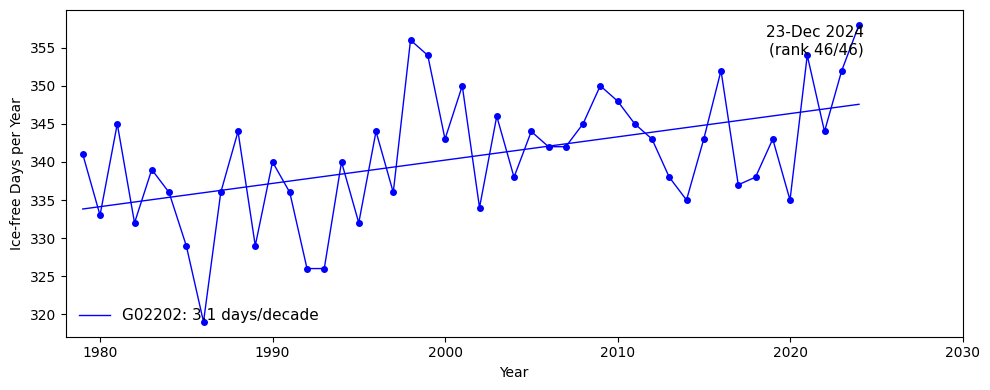

In [153]:
# Recreate G02202
metric = 'freezeup_day'  # breakup_day, freezeup_day, ifd

plt.figure(figsize=(10, 4))
ax = plt.gca()

name, ds = list(south_all.items())[-1]
data_slice = ds[metric].sel(extent_threshold=60, area_threshold=30, method='nearest')
years = data_slice['year'].values
vals = data_slice.values.astype(float)

# Remove NaNs
years = years[~np.isnan(vals)]
vals = vals[~np.isnan(vals)]

# Plot raw data (unlabeled)
ax.plot(years, vals, marker='o', markersize=4, linewidth=1, color='blue')

# Fit linear trend
x = (years - years[0]) / 10.0  # Convert to decades
slope, intercept, _, _, _ = linregress(x, vals)
trend_line = intercept + slope * x

# Plot trend line (labeled)
ax.plot(years, trend_line, linewidth=1, color='blue', label=f"G02202: {slope:.1f} days/decade")


# Add ranking text
latest_year = years[-1]
latest_val = vals[-1]
rank = np.sum(vals < latest_val) + 1
total = len(vals)

date_val = ds.freezeup_date.sel(year=latest_year, extent_threshold=60, area_threshold=30).values
if np.isnat(date_val):
    date_str = f"Date missing\n(rank {rank}/{total})"
else:
    date_str = f"{pd.to_datetime(date_val).strftime('%d-%b %Y')}\n(rank {rank}/{total})"

ax.annotate(
    date_str,
    xy=(latest_year, latest_val),
    xytext=(latest_year + 0.3, latest_val),
    fontsize=11,
    va='top', ha='right'
)


# Axis labels
ax.set_xlabel("Year")
ax.set_ylabel("Ice-free Days per Year")
ax.set_xlim(1978, 2030)

# Move legend outside
ax.legend(loc='lower left', frameon=False, fontsize=11)
plt.tight_layout()

plt.savefig(f"../figures/G02202_South_{metric}.png", dpi=300, bbox_inches='tight')

plt.show()

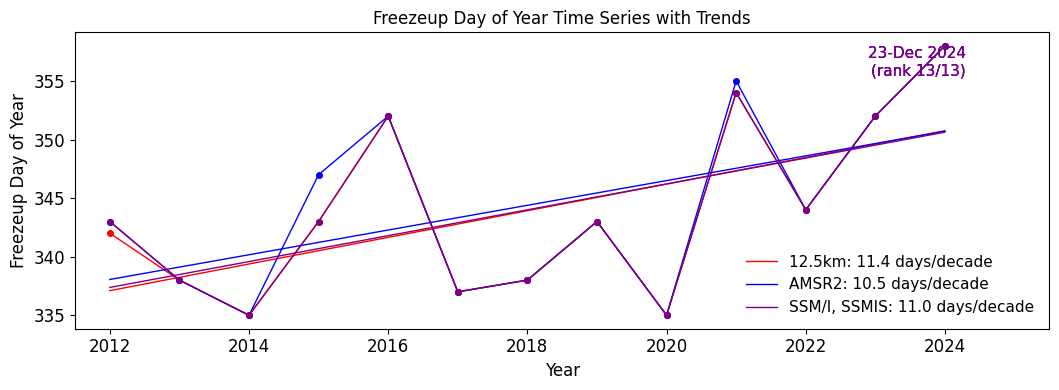

In [156]:
keys_to_keep = ['AMSR2_12.5km_2012_2025', 'AMSR2_25km_2012_2025', 'G02202_25km_1978_2025']
filtered_south_all = {k: v for k, v in south_all.items() if k in keys_to_keep}

metric = 'freezeup_day'  # breakup_day, freezeup_day, ifd

plt.figure(figsize=(11, 4))
ax = plt.gca()

# Proper color cycle
colors = ['red', 'blue', 'purple']
labels = ['12.5km', 'AMSR2', 'SSM/I, SSMIS']

for i, (name, ds) in enumerate(filtered_south_all.items()):
    data_slice = ds[metric].sel(year=slice(2012, 2025))
    data_slice = data_slice.sel(extent_threshold=60, area_threshold=30, method='nearest')
    years = data_slice['year'].values
    vals = data_slice.values.astype(float)

    # Remove NaNs
    years = years[~np.isnan(vals)]
    vals = vals[~np.isnan(vals)]
    if len(years) == 0:
        print(f"Skipping {name} due to no valid data.")
        continue

    # Plot raw data (unlabeled)
    ax.plot(years, vals, marker='o', markersize=4, linewidth=1, color=colors[i])

    # Fit linear trend
    x = (years - years[0]) / 10.0  # Convert to decades
    slope, intercept, _, _, _ = linregress(x, vals)
    trend_line = intercept + slope * x

    # Plot trend line (labeled)
    ax.plot(years, trend_line, linewidth=1, color=colors[i], label=f"{labels[i]}: {slope:.1f} days/decade")

    # Add ranking text
    latest_year = years[-1]
    latest_val = vals[-1]
    rank = np.sum(vals < latest_val) + 1
    total = len(vals)

    date_val = ds.freezeup_date.sel(year=latest_year, extent_threshold=60, area_threshold=30).values
    if np.isnat(date_val):
        date_str = f"Date missing\n(rank {rank}/{total})"
    else:
        date_str = f"{pd.to_datetime(date_val).strftime('%d-%b %Y')}\n(rank {rank}/{total})"

    ax.annotate(
        date_str,
        xy=(latest_year, latest_val),
        xytext=(latest_year + 0.3, latest_val),
        fontsize=11,
        color=colors[i],
        va='top', ha='right'
    )

# Axis labels and title
ylabel = {
    'breakup_day': 'Breakup Day of Year',
    'freezeup_day': 'Freezeup Day of Year',
    'ifd': 'Ice-Free Days'
}.get(metric, metric)

ax.set_ylabel(ylabel, fontsize=12)
ax.set_xlabel("Year", fontsize=12)
ax.set_title(f"{ylabel} Time Series with Trends", fontsize=12)
ax.set_xlim(2011.5, 2025.5)

# Make tick labels bigger
ax.tick_params(axis='both', which='major', labelsize=12)

# Move legend outside
ax.legend(loc='lower left', frameon=False, bbox_to_anchor=(0.675, 0), fontsize=11)

plt.tight_layout()

# Save figure (change filename as you want)
plt.savefig(f"../figures/South_{metric}_2012_2025.png", dpi=300, bbox_inches='tight')

plt.show()

#### All Data

/glade/derecho/scratch/skygale/tmp/ipykernel_18110/4111224206.py:62: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  slope, intercept, r_value, p_value, std_err = linregress(x, vals)


No valid data for NSIDC_0803_25km_2023_2025 metric 'breakup_day' at ext=60, area=30
No valid data for NSIDC_0803_25km_2023_2025 metric 'ifd' at ext=60, area=30
No valid data for NSIDC_0803_25km_2023_2025 metric 'breakup_day' at ext=60, area=30
No valid data for NSIDC_0803_25km_2023_2025 metric 'ifd' at ext=60, area=30


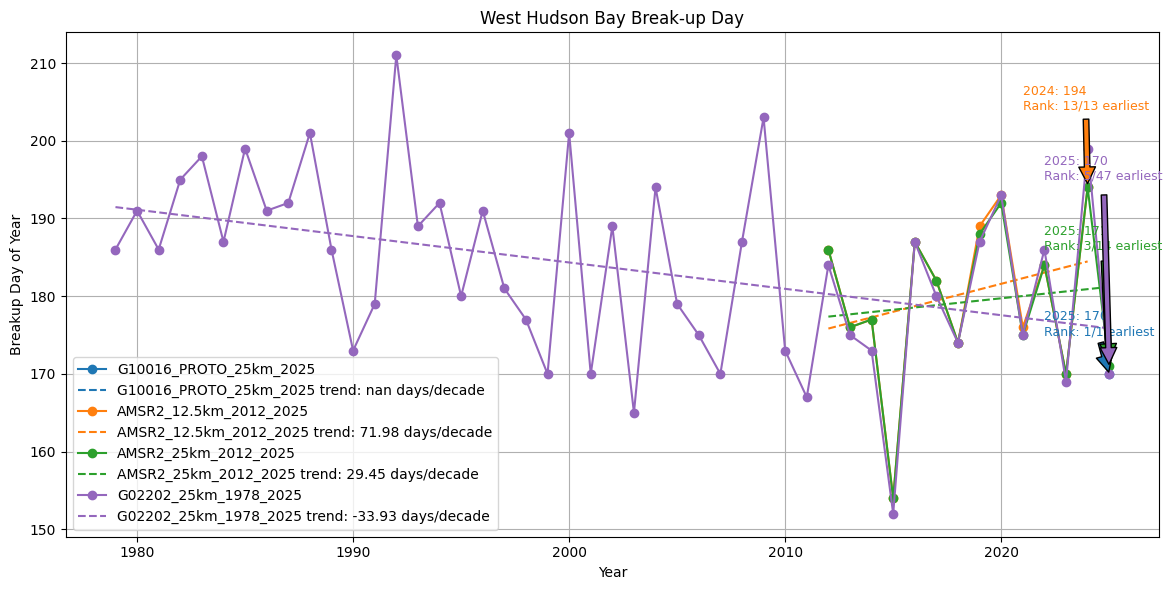

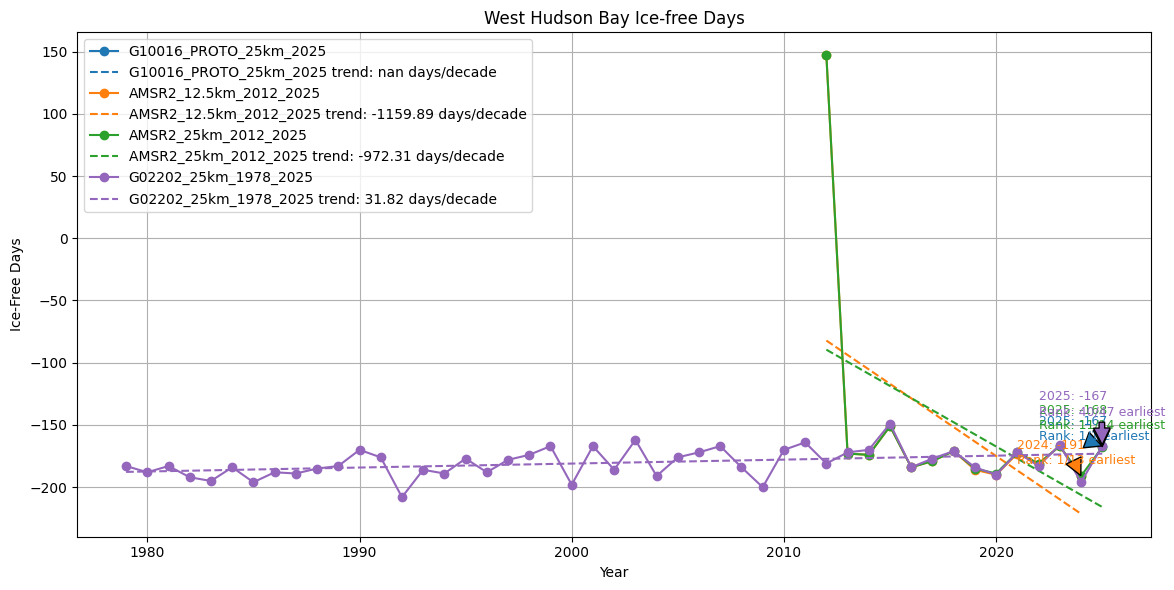

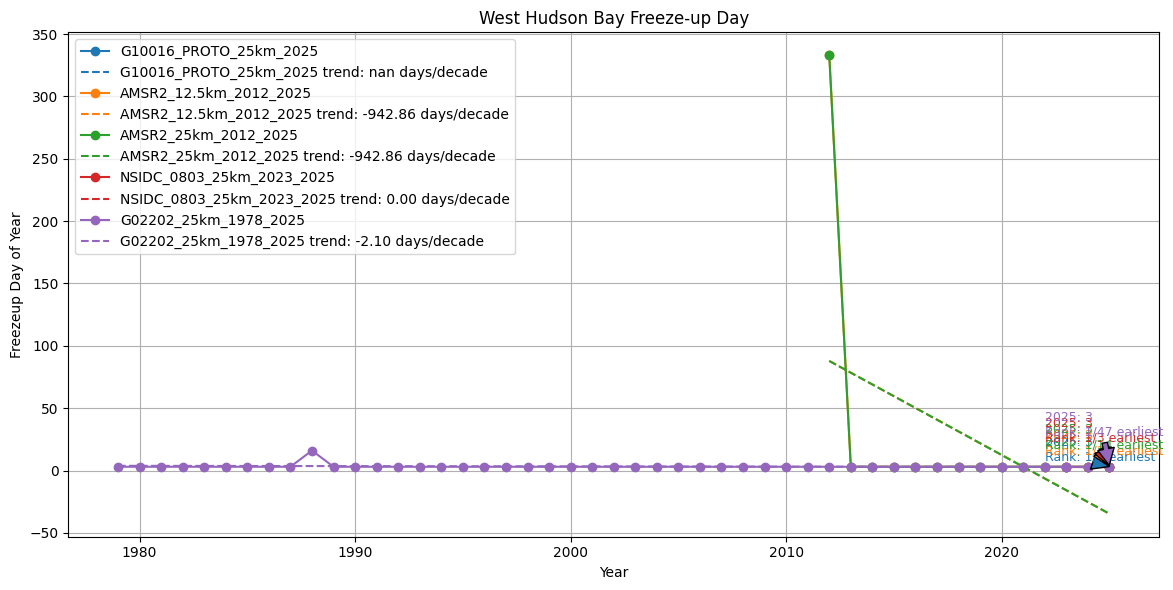

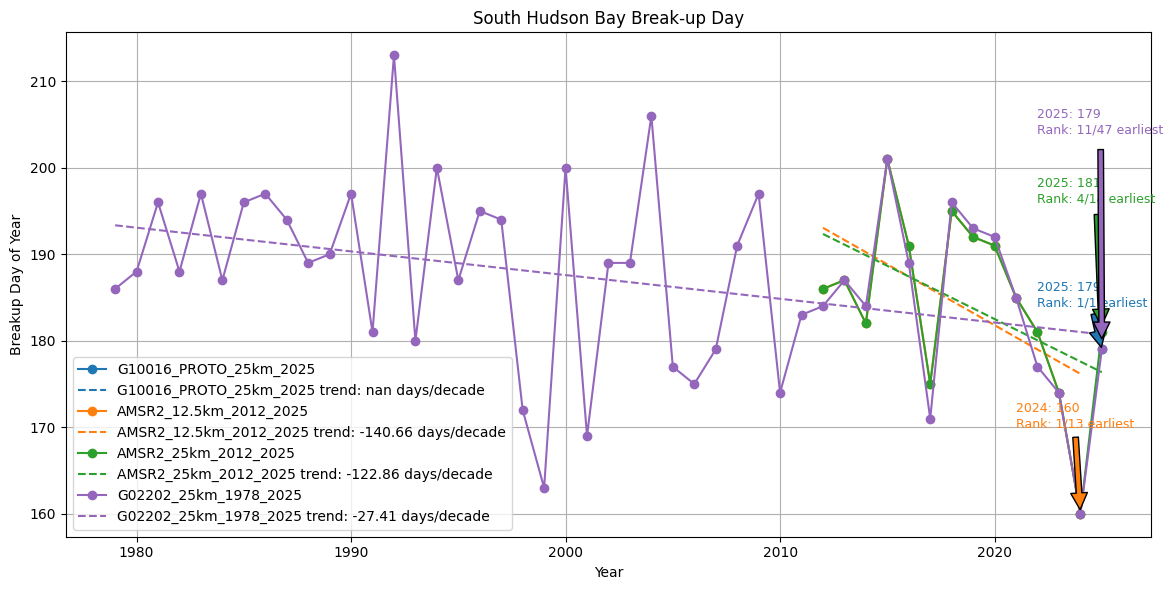

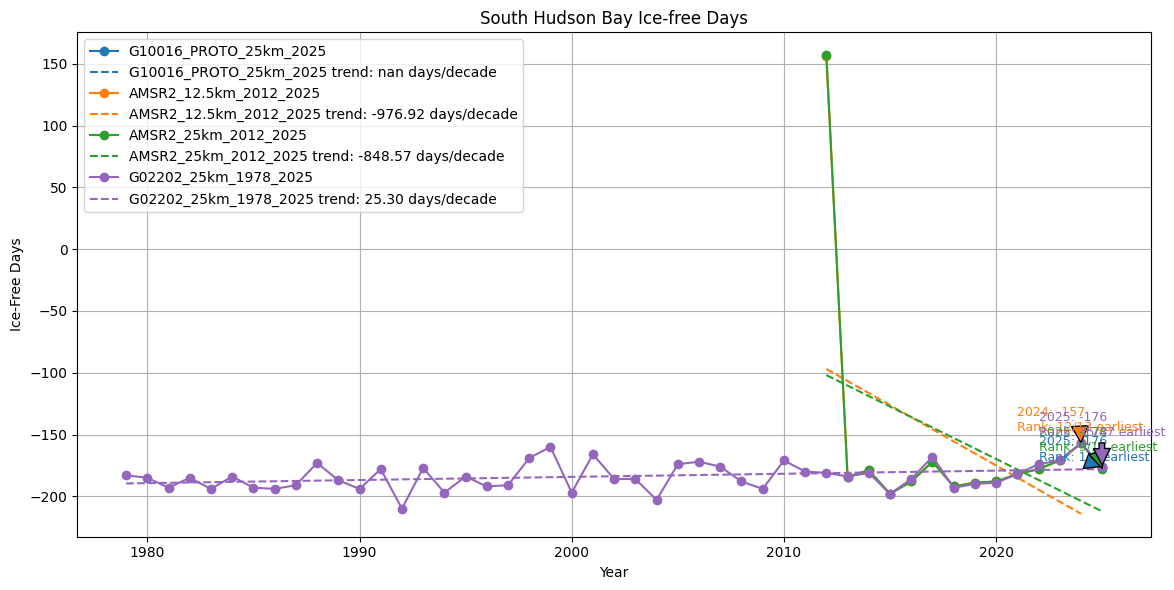

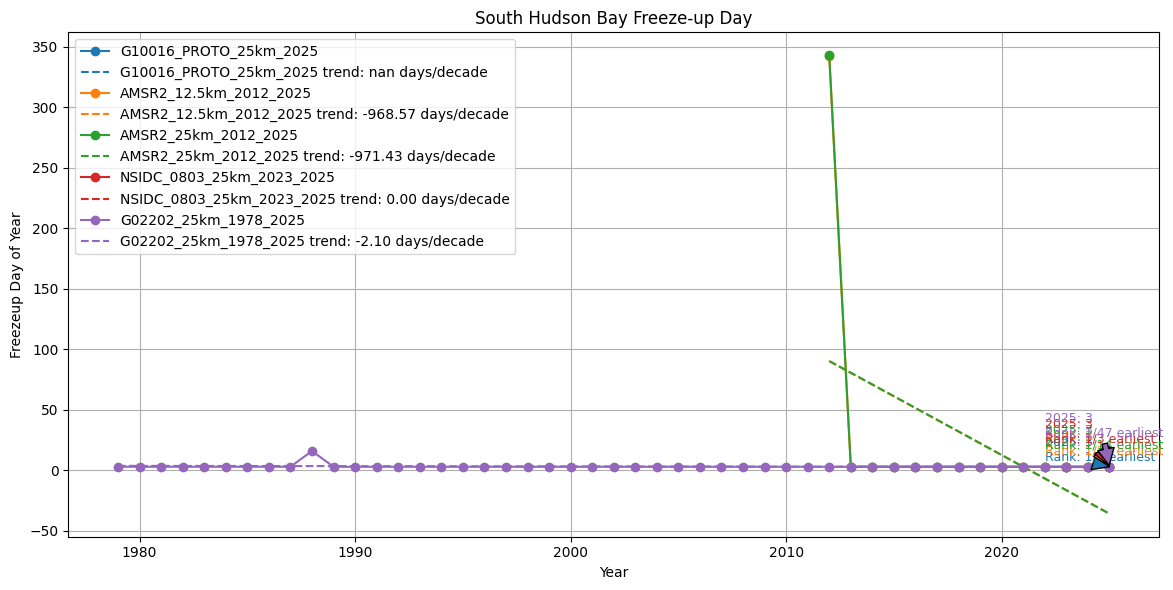

In [31]:
# Set extent and area parameters
extent = 60
area = 30

metrics = ['breakup_day', 'ifd', 'freezeup_day']
titles = ['Break-up Day', 'Ice-free Days', 'Freeze-up Day']

# Plots for West Hudson Bay
for metric, title in zip(metrics, titles):
    plot_ice_metric_time_series(
        west_all,
        metric=metric,
        extent_threshold=extent,
        area_threshold=area,
        title='West Hudson Bay '+title)

# Plots for South Hudson Bay
for metric, title in zip(metrics, titles):
    plot_ice_metric_time_series(
        south_all,
        metric=metric,
        extent_threshold=extent,
        area_threshold=area,
        title='South Hudson Bay '+title)

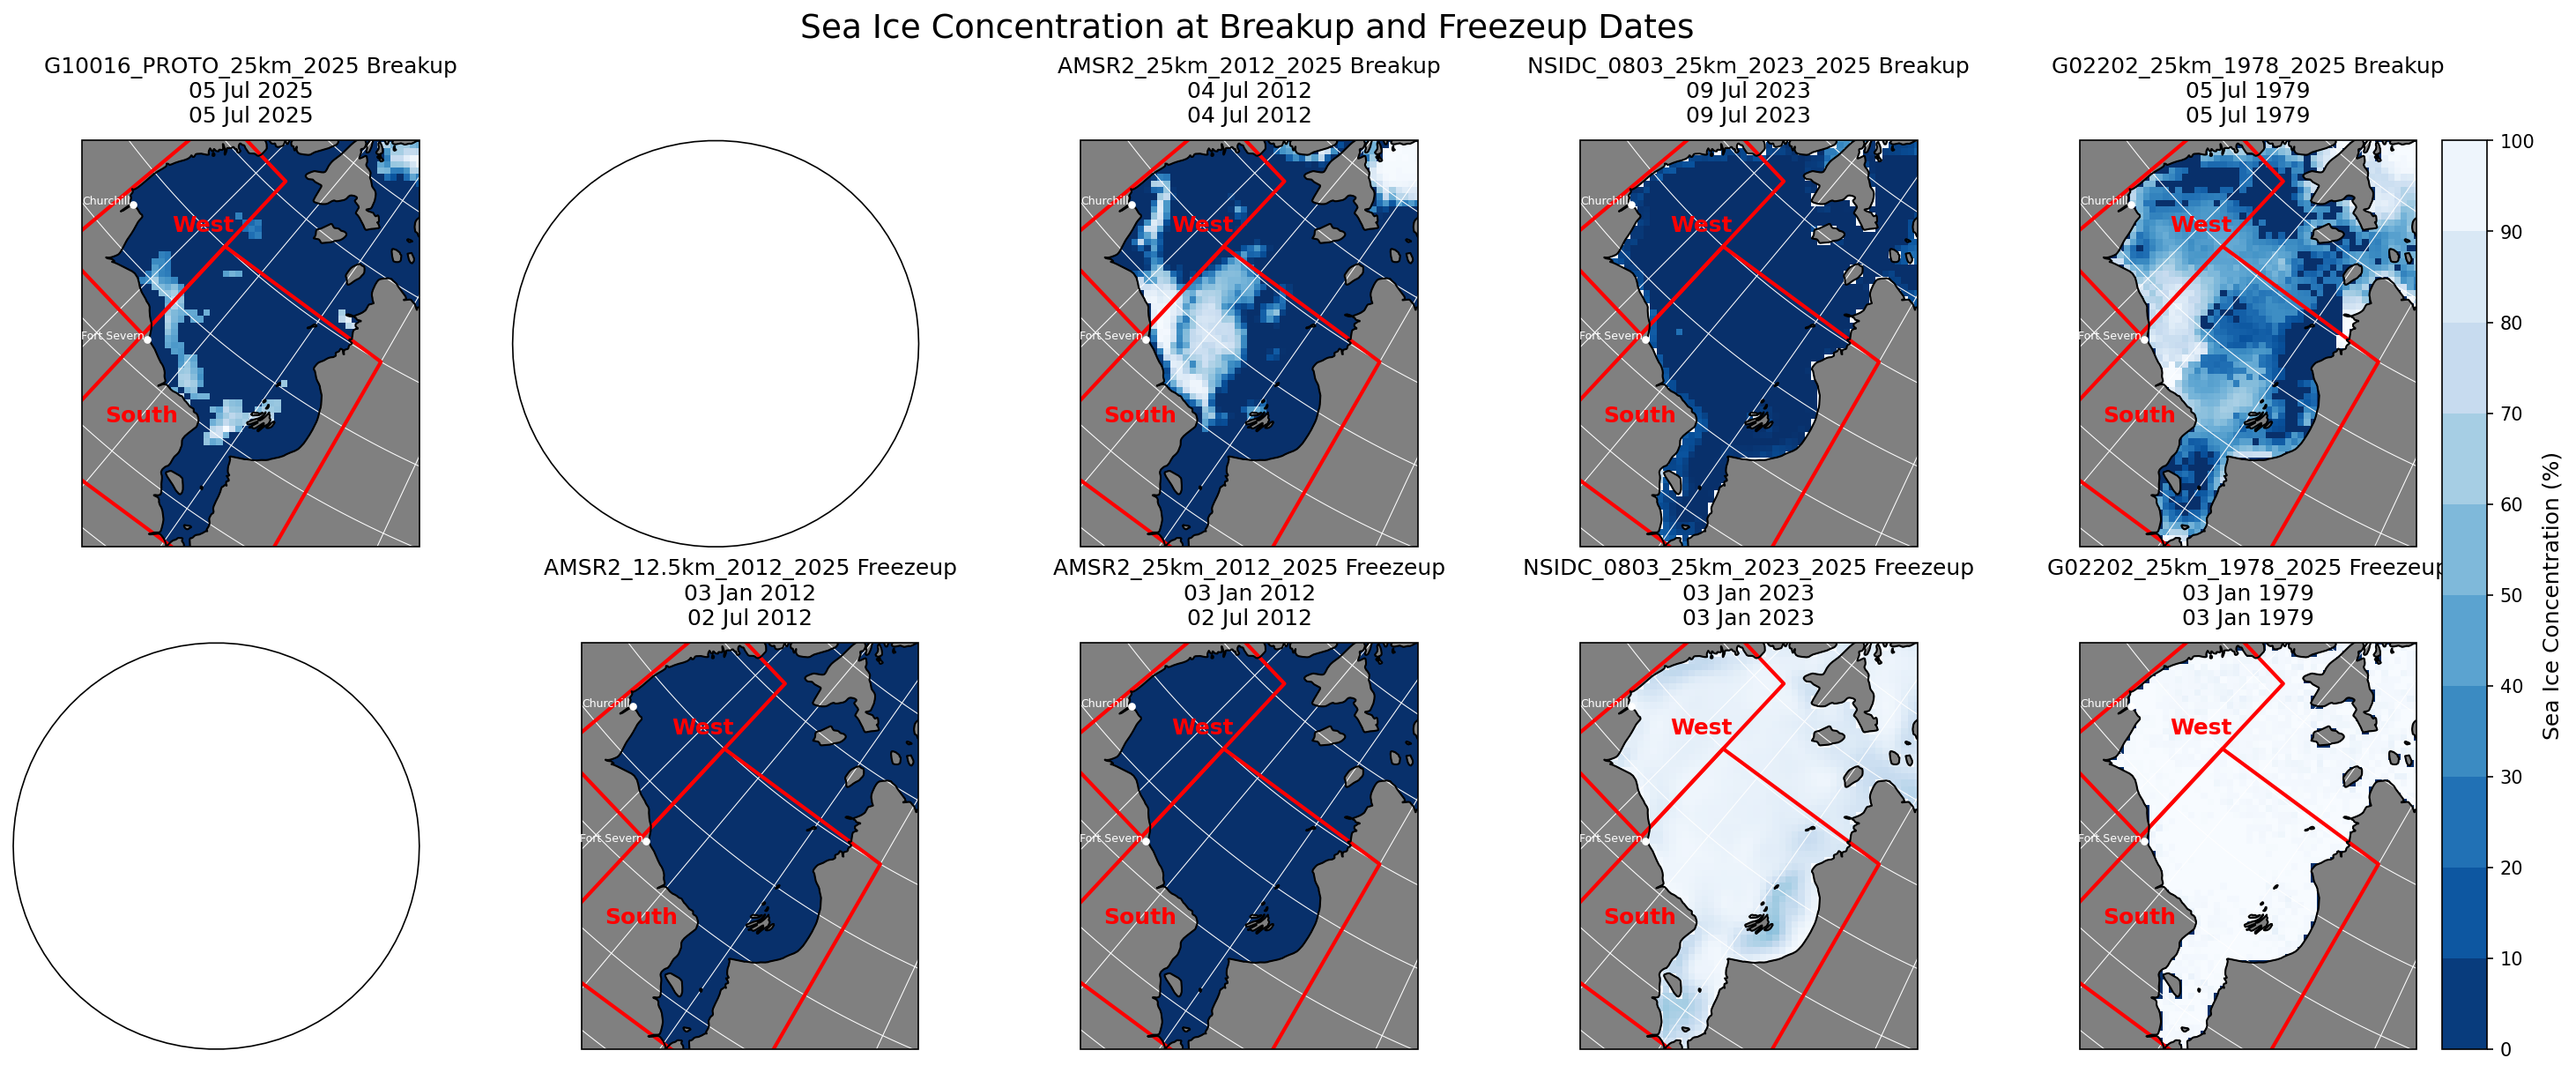

In [39]:
def day_of_year_to_date(year, doy):
    # Convert day of year (doy) to datetime object
    return datetime(year, 1, 1) + timedelta(days=int(doy) - 1)

# Get breakup and freezeup dates
breakup_dates_west, freezeup_dates_west = get_dates(west_all)
breakup_dates_south, freezeup_dates_south = get_dates(south_all)

# Define projections
crs = ccrs.Stereographic(
    central_latitude=90,
    central_longitude=-45
)

crs_nsidc = ccrs.Stereographic(
    central_latitude=90,
    central_longitude=-45,
    true_scale_latitude=70,
    false_easting=0,
    false_northing=0
)

# Plot SIC on those dates
fig, axs = plt.subplots(2, 5, figsize=(20, 8), dpi=150, subplot_kw={'projection': crs}, constrained_layout=True)
ims = []

for d, ax in enumerate(axs[0]):  # top row: breakup
    ds = ds_all[d]
    name = names[d]
    doy_array = breakup_dates_west.get(name)
    if doy_array is None or np.isnan(doy_array).all():
        continue
    
    # Choose the specific day of year - here I take the first non-NaN value in the array
    # You can adjust the indices or selection logic as needed
    doy = None
    for val in doy_array.flatten():
        if not np.isnan(val):
            doy = val
            break
    if doy is None:
        continue
    
    # Extract year from dataset time coordinate (assuming ds.time is datetime64)
    year = pd.to_datetime(ds.time.values[0]).year
    breakup_date = day_of_year_to_date(year, doy)
    
    t_idx = get_time_index(ds, breakup_date)
    ds_sel = ds.isel(time=t_idx)
    im = plot_hudsonbay_all(ds_sel, f"{name} Breakup\n{breakup_date.strftime('%d %b %Y')}", ax, crs, crs_nsidc)
    ims.append(im)

for d, ax in enumerate(axs[1]):  # bottom row: freezeup
    ds = ds_all[d]
    name = names[d]
    doy_array = freezeup_dates_west.get(name)
    if doy_array is None or np.isnan(doy_array).all():
        continue
    
    doy = None
    for val in doy_array.flatten():
        if not np.isnan(val):
            doy = val
            break
    if doy is None:
        continue
    
    year = pd.to_datetime(ds.time.values[0]).year
    freezeup_date = day_of_year_to_date(year, doy)
    
    t_idx = get_time_index(ds, freezeup_date)
    ds_sel = ds.isel(time=t_idx)
    im = plot_hudsonbay_all(ds_sel, f"{name} Freezeup\n{freezeup_date.strftime('%d %b %Y')}", ax, crs, crs_nsidc)
    ims.append(im)

# Shared colorbar (using last im)
levels = np.linspace(0, 100, 11)
cbar = fig.colorbar(ims[-1], ax=axs.ravel().tolist(), orientation='vertical', boundaries=levels, ticks=levels, fraction=0.05, pad=0.01)
cbar.set_label('Sea Ice Concentration (%)', fontsize=12)

plt.suptitle('Sea Ice Concentration at Breakup and Freezeup Dates', fontsize=18)
plt.show()
